<div style="text-align: center;">
  <img src="https://drive.google.com/uc?id=1i7D7Ybh8_UY7BkWFpN_7cZ5Oga_4wkdK" width="270" height="100">
</div>

# **Chunking eficiente para RAG: calidad vs. costo computacional**

* **Luna Catalina Martínez Vásquez — A00401964**
* **Renzo Fernando Mosquera Daza — A00401681**

---

**Curso:** Inteligencia Artificial  
**Artículo base:** *Is Semantic Chunking Worth the Computational Cost?* — Qu, Tu y Bao, NAACL 2025 https://doi.org/10.18653/v1/2025.findings-naacl.114


## **Contexto**

En un sistema **Retrieval-Augmented Generation (RAG)**, los documentos largos se dividen en partes más pequeñas llamadas *chunks*. Luego, cuando llega una consulta, el sistema compara esa pregunta con los fragmentos disponibles y recupera los que parecen tener la información más útil.

Cuando revisamos el artículo base, vimos que compara estrategias de tamaño fijo con estrategias semánticas. El paper muestra que el *semantic chunking* puede mejorar algunos casos, pero también deja claro que esas mejoras no siempre son consistentes y que el costo computacional puede aumentar.

A partir de eso, nosotros decidimos comparar tres enfoques: **Fixed-size**, **Semantic breakpoint** y **Structure-aware**. Los dos primeros nos permiten representar una estrategia simple y una estrategia semántica, mientras que con **Structure-aware** quisimos probar una opción que aprovecha la forma en la que ya viene organizado el documento.

### **Hipótesis de trabajo**

Nuestra idea es que, si usamos límites naturales como párrafos o secciones, podemos conservar mejor información relacionada sin tener que calcular embeddings adicionales para decidir cada corte.

## **Preparación**

Para representar el significado de las oraciones utilizamos `sentence-transformers/all-MiniLM-L6-v2`. Escogimos este modelo porque es relativamente ligero y nos permite correr toda la demostración sin necesitar demasiados recursos.

In [ ]:
!pip -q install sentence-transformers pandas numpy matplotlib scikit-learn

In [ ]:
import time
import random
from dataclasses import dataclass
from typing import List, Dict, Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from IPython.display import display, HTML

# Semilla fija para mantener resultados reproducibles.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Modelo ligero de embeddings usado en toda la demostración.
MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
embedder = SentenceTransformer(MODEL_NAME)

print("Modelo:", MODEL_NAME)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Modelo: sentence-transformers/all-MiniLM-L6-v2


## **Documento de demostración**

Para esta parte construimos un **mini-documento controlado** con tres párrafos. Cada bloque habla de un tema relacionado con lo que queremos explicar:

- funcionamiento de RAG;
- estrategias de chunking;
- costo computacional.

También numeramos cada oración como `S0`, `S1`, ... porque así podemos saber exactamente qué oraciones esperamos recuperar en cada pregunta. Esto nos sirve para comparar las estrategias sin depender de una evaluación subjetiva.

A propósito dejamos los párrafos con tamaños distintos. Así **Fixed-size** no termina haciendo exactamente los mismos cortes que **Structure-aware**, y podemos ver mejor qué cambia cuando una estrategia respeta la estructura del documento.


In [ ]:
# Documento controlado dividido en tres bloques temáticos.
# Los párrafos tienen tamaños distintos para poder comparar realmente
# un corte fijo contra uno que respeta la estructura del documento.
PARAGRAPHS = [
    [
        "Retrieval-augmented generation combines a language model with an external collection of documents.",
        "Before retrieval, long documents are usually divided into smaller units called chunks.",
        "A retriever compares a user query with chunk representations and selects the most relevant pieces of text.",
    ],
    [
        "The way these chunks are defined influences which context is later supplied to the language model.",
        "Fixed-size chunking divides text at regular intervals and is inexpensive to compute.",
        "However, a fixed boundary can separate sentences that belong to the same idea.",
        "Semantic breakpoint chunking compares neighboring sentences and places a boundary when their meanings change substantially.",
        "This semantic decision requires additional embedding computations before the chunks are created.",
    ],
    [
        "More sophisticated chunking does not automatically produce better retrieval.",
        "A small quality improvement may be unattractive if preprocessing becomes much slower or produces many more chunks.",
        "Documents such as scientific articles already contain useful structural signals including paragraphs and sections.",
        "A structure-aware strategy can exploit those boundaries without computing semantic distances for every possible cut.",
    ],
]

SENTENCES = [sentence for paragraph in PARAGRAPHS for sentence in paragraph]

sentence_to_paragraph = {}
cursor = 0
for paragraph_id, paragraph in enumerate(PARAGRAPHS):
    for _ in paragraph:
        sentence_to_paragraph[cursor] = paragraph_id
        cursor += 1

for i, sentence in enumerate(SENTENCES):
    print(f"S{i}: {sentence}")


S0: Retrieval-augmented generation combines a language model with an external collection of documents.
S1: Before retrieval, long documents are usually divided into smaller units called chunks.
S2: A retriever compares a user query with chunk representations and selects the most relevant pieces of text.
S3: The way these chunks are defined influences which context is later supplied to the language model.
S4: Fixed-size chunking divides text at regular intervals and is inexpensive to compute.
S5: However, a fixed boundary can separate sentences that belong to the same idea.
S6: Semantic breakpoint chunking compares neighboring sentences and places a boundary when their meanings change substantially.
S7: This semantic decision requires additional embedding computations before the chunks are created.
S8: More sophisticated chunking does not automatically produce better retrieval.
S9: A small quality improvement may be unattractive if preprocessing becomes much slower or produces many more

### **Preguntas y evidencia esperada**

Definimos tres preguntas sencillas sobre el documento. Para cada una marcamos manualmente las oraciones que contienen la evidencia correcta. Esa información queda en `gold_sentence_ids` y después la usamos para calcular las métricas de recuperación.

In [ ]:
# Cada pregunta tiene asociadas las oraciones esperadas como evidencia.
QUESTIONS = pd.DataFrame([
    {
        "question": "Why can fixed-size chunking be problematic?",
        "gold_sentence_ids": {4, 5},
    },
    {
        "question": "Why is semantic breakpoint chunking more computationally expensive?",
        "gold_sentence_ids": {6, 7},
    },
    {
        "question": "What information can a structure-aware strategy exploit?",
        "gold_sentence_ids": {10, 11},
    },
])

display(QUESTIONS)

,question,gold_sentence_ids
0,Why can fixed-size chunking be problematic?,"{4, 5}"
1,Why is semantic breakpoint chunking more compu...,"{6, 7}"
2,What information can a structure-aware strateg...,"{10, 11}"


### **Criterio de segmentación**

Una de las cosas que quisimos mostrar es que el mismo documento puede quedar dividido de maneras distintas según el criterio usado. En esta parte se ve precisamente esa diferencia: cada estrategia decide de otra forma dónde termina un chunk y dónde comienza el siguiente.

## **Implementación de los tres chunkers**

### **Fixed-size**

En este caso agrupamos un número fijo de oraciones por chunk. Es la estrategia más directa y además permite usar *overlap* para repetir parte del contenido entre fragmentos consecutivos.

### **Semantic breakpoint**

Aquí utilizamos embeddings para comparar oraciones consecutivas. Calculamos su distancia coseno y tomamos los cambios semánticos más fuertes como posibles puntos de corte.

### **Structure-aware**

Para esta estrategia no calculamos una distancia semántica antes de cortar. En cambio, usamos directamente los límites de los párrafos. La idea es aprovechar información estructural que el documento ya trae y que, en textos científicos, también podría extenderse a secciones o subtítulos.

In [ ]:
@dataclass
class Chunk:
    name: str
    sentence_ids: List[int]
    text: str


def make_chunk(name: str, sentence_ids: Iterable[int]) -> Chunk:
    ids = list(sentence_ids)
    return Chunk(
        name=name,
        sentence_ids=ids,
        text=" ".join(SENTENCES[i] for i in ids),
    )


def fixed_size_chunker(chunk_size: int = 4, overlap: int = 0) -> List[Chunk]:
    chunks = []
    step = max(1, chunk_size - overlap)

    for start in range(0, len(SENTENCES), step):
        ids = list(range(start, min(start + chunk_size, len(SENTENCES))))
        if ids:
            chunks.append(make_chunk("Fixed-size", ids))
        if ids and ids[-1] == len(SENTENCES) - 1:
            break

    return chunks


def cosine_distance(a: np.ndarray, b: np.ndarray) -> float:
    # Los embeddings de SentenceTransformer se normalizan en esta demostración.
    return float(1.0 - np.dot(a, b))


def semantic_breakpoint_chunker(n_chunks: int = 3):
    # Este costo es adicional: fixed-size y structure-aware no lo necesitan.
    sentence_embeddings = embedder.encode(
        SENTENCES,
        normalize_embeddings=True,
        convert_to_numpy=True,
        show_progress_bar=False,
    )

    distances = np.array([
        cosine_distance(sentence_embeddings[i], sentence_embeddings[i + 1])
        for i in range(len(SENTENCES) - 1)
    ])

    # Elegimos los n_chunks - 1 cambios semánticos consecutivos más fuertes.
    n_breaks = max(0, min(n_chunks - 1, len(distances)))
    break_after = sorted(np.argsort(-distances)[:n_breaks].tolist())

    chunks = []
    start = 0

    for boundary in break_after:
        end = boundary + 1
        chunks.append(make_chunk("Semantic breakpoint", range(start, end)))
        start = end

    if start < len(SENTENCES):
        chunks.append(make_chunk("Semantic breakpoint", range(start, len(SENTENCES))))

    return chunks, distances, break_after


def structure_aware_chunker() -> List[Chunk]:
    chunks = []
    cursor = 0

    for paragraph in PARAGRAPHS:
        ids = list(range(cursor, cursor + len(paragraph)))
        chunks.append(make_chunk("Structure-aware", ids))
        cursor += len(paragraph)

    return chunks

## **Construcción y visualización de los chunks**

Con las tres funciones listas, construimos los chunks sobre exactamente el mismo documento. De esta forma podemos comparar las diferencias sin cambiar el contenido de entrada.

In [ ]:
# Construimos los chunks de las tres estrategias bajo el mismo documento.
fixed_chunks = fixed_size_chunker(chunk_size=4, overlap=0)
semantic_chunks, semantic_distances, semantic_breaks = semantic_breakpoint_chunker(n_chunks=3)
structure_chunks = structure_aware_chunker()

CHUNKERS = {
    "Fixed-size": fixed_chunks,
    "Semantic breakpoint": semantic_chunks,
    "Structure-aware": structure_chunks,
}

print("Breakpoints semánticos después de las oraciones:", semantic_breaks)

Breakpoints semánticos después de las oraciones: [2, 9]


In [ ]:
def show_chunks(title: str, chunks: List[Chunk]):
    html = [f"<h3>{title}</h3>"]

    for j, chunk in enumerate(chunks, start=1):
        ids = ", ".join(f"S{i}" for i in chunk.sentence_ids)
        html.append(
            f'''
            <div style="
                border:1px solid #bbb;
                border-radius:10px;
                padding:12px;
                margin:8px 0;
                background:#fafafa;">
                <b>Chunk {j}</b> — {ids}<br>
                <span>{chunk.text}</span>
            </div>
            '''
        )

    display(HTML("".join(html)))


for name, chunks in CHUNKERS.items():
    show_chunks(name, chunks)

### **Comparación visual**

Al visualizar los resultados vemos que las tres estrategias no necesariamente colocan los cortes en los mismos lugares.

**Fixed-size** se guía únicamente por la posición de las oraciones y, con la configuración que usamos, corta cada cuatro oraciones. **Semantic breakpoint** usa la información de los embeddings para buscar cambios de significado. **Structure-aware**, en cambio, conserva los límites de los tres párrafos que nosotros definimos.

En nuestro ejemplo los párrafos tienen 3, 5 y 4 oraciones. Esto hace que la diferencia entre un corte fijo y un corte basado en estructura sí sea visible. También nos permite revisar si una estrategia termina separando una idea o si conserva juntos los bloques que originalmente pertenecían al mismo párrafo.


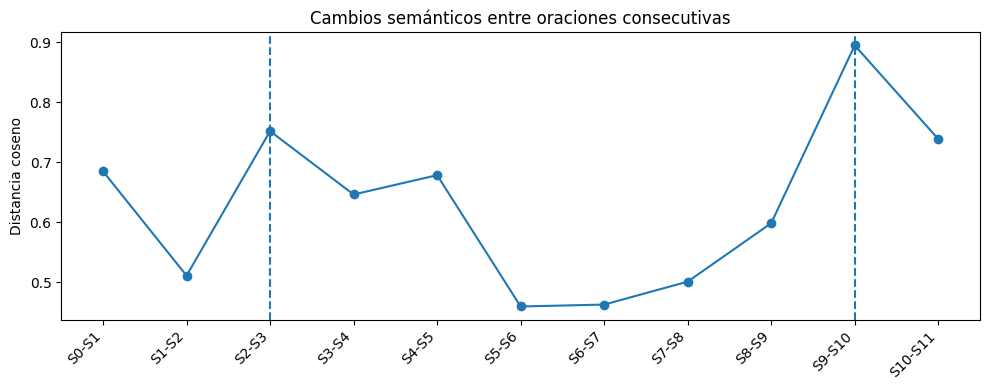

In [ ]:
plt.figure(figsize=(10, 4))
x = np.arange(len(semantic_distances))

plt.plot(x, semantic_distances, marker="o")
for boundary in semantic_breaks:
    plt.axvline(boundary, linestyle="--")

plt.xticks(x, [f"S{i}-S{i+1}" for i in x], rotation=45, ha="right")
plt.ylabel("Distancia coseno")
plt.title("Cambios semánticos entre oraciones consecutivas")
plt.tight_layout()
plt.show()

## **Recuperación de evidencia**

Después de construir los chunks, usamos el mismo procedimiento de recuperación para las tres estrategias. Esto es importante porque queremos que la diferencia venga del **chunking** y no de cambiar también la forma de hacer la búsqueda.

Nosotros convertimos la pregunta en un embedding, calculamos su similitud coseno con cada chunk y ordenamos los resultados de mayor a menor similitud. Para mantener el ejemplo fácil de seguir, recuperamos el chunk con mayor puntuación.

In [ ]:
def embed_texts(texts: List[str]) -> np.ndarray:
    return embedder.encode(
        texts,
        normalize_embeddings=True,
        convert_to_numpy=True,
        show_progress_bar=False,
    )


def index_chunks(chunks: List[Chunk]):
    embeddings = embed_texts([chunk.text for chunk in chunks])
    return embeddings


# Recuperación basada en similitud coseno entre consulta y chunks.
def retrieve(question: str, chunks: List[Chunk], chunk_embeddings: np.ndarray, k: int = 1):
    query = embed_texts([question])[0]
    scores = chunk_embeddings @ query
    order = np.argsort(-scores)[:k]

    return [
        {
            "rank": rank + 1,
            "score": float(scores[idx]),
            "sentence_ids": chunks[idx].sentence_ids,
            "text": chunks[idx].text,
        }
        for rank, idx in enumerate(order)
    ]

### **Consulta de ejemplo**

Con `QUESTION_ID` escogemos una de las tres preguntas que definimos al inicio. Primero mostramos cuál era la evidencia que esperábamos recuperar y después vemos qué fragmento encontró cada estrategia.

In [ ]:
# Selección de la consulta usada en el ejemplo de recuperación.
QUESTION_ID = 1

selected_question = QUESTIONS.iloc[QUESTION_ID]
question = selected_question["question"]

print("Pregunta:")
print(question)
print("\nEvidencia esperada:")
print(sorted(selected_question["gold_sentence_ids"]))

Pregunta:
Why is semantic breakpoint chunking more computationally expensive?

Evidencia esperada:
[6, 7]


In [ ]:
indexed = {
    name: index_chunks(chunks)
    for name, chunks in CHUNKERS.items()
}

for name, chunks in CHUNKERS.items():
    print("\n" + "=" * 90)
    print(name)
    results = retrieve(question, chunks, indexed[name], k=1)

    for result in results:
        print(
            f"Top {result['rank']} | similitud={result['score']:.3f} | "
            f"oraciones={result['sentence_ids']}"
        )
        print(result["text"])


Fixed-size
Top 1 | similitud=0.771 | oraciones=[4, 5, 6, 7]
Fixed-size chunking divides text at regular intervals and is inexpensive to compute. However, a fixed boundary can separate sentences that belong to the same idea. Semantic breakpoint chunking compares neighboring sentences and places a boundary when their meanings change substantially. This semantic decision requires additional embedding computations before the chunks are created.

Semantic breakpoint
Top 1 | similitud=0.766 | oraciones=[3, 4, 5, 6, 7, 8, 9]
The way these chunks are defined influences which context is later supplied to the language model. Fixed-size chunking divides text at regular intervals and is inexpensive to compute. However, a fixed boundary can separate sentences that belong to the same idea. Semantic breakpoint chunking compares neighboring sentences and places a boundary when their meanings change substantially. This semantic decision requires additional embedding computations before the chunks are 

## **Evaluación de recuperación**

Para medir qué tan bien funcionó la recuperación usamos tres métricas a nivel de oración:

- **Precision:** nos dice qué proporción de las oraciones recuperadas realmente pertenecía a la evidencia esperada.
- **Recall:** nos indica qué parte de toda la evidencia esperada logramos recuperar.
- **F1:** combina precision y recall en un solo valor para no mirar únicamente una de las dos.

En este ejemplo trabajamos con el `top-1 chunk`. Lo hicimos así porque permite ver de manera directa qué efecto tuvo cada forma de segmentar el documento.

In [ ]:
def prf1(retrieved_ids: set, gold_ids: set):
    intersection = len(retrieved_ids & gold_ids)
    precision = intersection / len(retrieved_ids) if retrieved_ids else 0.0
    recall = intersection / len(gold_ids) if gold_ids else 0.0

    if precision + recall == 0:
        f1 = 0.0
    else:
        f1 = 2 * precision * recall / (precision + recall)

    return precision, recall, f1


def evaluate_chunker(chunks: List[Chunk], chunk_embeddings: np.ndarray):
    rows = []

    for _, row in QUESTIONS.iterrows():
        result = retrieve(row["question"], chunks, chunk_embeddings, k=1)[0]
        retrieved_ids = set(result["sentence_ids"])
        gold_ids = set(row["gold_sentence_ids"])

        precision, recall, f1 = prf1(retrieved_ids, gold_ids)

        rows.append({
            "question": row["question"],
            "precision": precision,
            "recall": recall,
            "f1": f1,
        })

    return pd.DataFrame(rows)

## **Costo computacional**

Además de revisar la calidad, también medimos cuánto cuesta preparar cada estrategia. Separamos ese costo en dos partes:

- **Chunking:** tiempo que usamos para decidir los cortes y construir los fragmentos.
- **Indexación:** tiempo necesario para generar los embeddings finales con los que hacemos la recuperación.

En **Semantic breakpoint** hay un paso adicional: antes de crear los chunks necesitamos obtener embeddings de las oraciones para decidir dónde cortar. Por eso esperamos que tenga un costo de preprocesamiento mayor que las otras dos alternativas.

Como esta demostración trabaja con un documento muy pequeño, los tiempos sirven principalmente para comparar las estrategias **dentro de la misma ejecución**. No los tomamos como tiempos universales porque pueden variar según el hardware, la carga del entorno y la caché del modelo.


In [ ]:
# Ejecutamos cada estrategia y medimos calidad y tiempos.
def run_strategy(name: str):
    start = time.perf_counter()

    if name == "Fixed-size":
        chunks = fixed_size_chunker(chunk_size=4, overlap=0)

    elif name == "Semantic breakpoint":
        chunks, _, _ = semantic_breakpoint_chunker(n_chunks=3)

    elif name == "Structure-aware":
        chunks = structure_aware_chunker()

    else:
        raise ValueError(name)

    chunking_seconds = time.perf_counter() - start

    start_index = time.perf_counter()
    chunk_embeddings = index_chunks(chunks)
    indexing_seconds = time.perf_counter() - start_index

    scores = evaluate_chunker(chunks, chunk_embeddings)

    return {
        "chunker": name,
        "precision": scores["precision"].mean(),
        "recall": scores["recall"].mean(),
        "f1": scores["f1"].mean(),
        "chunking_ms": chunking_seconds * 1000,
        "indexing_ms": indexing_seconds * 1000,
        "total_ms": (chunking_seconds + indexing_seconds) * 1000,
        "n_chunks": len(chunks),
        "avg_sentences_per_chunk": np.mean([len(c.sentence_ids) for c in chunks]),
    }


# Warm-up: para evitar que la primera llamada al modelo distorsione excesivamente el tiempo.
_ = embed_texts(["warm up"])

rows = [
    run_strategy("Fixed-size"),
    run_strategy("Semantic breakpoint"),
    run_strategy("Structure-aware"),
]

results = pd.DataFrame(rows)
display(
    results.style.format({
        "precision": "{:.3f}",
        "recall": "{:.3f}",
        "f1": "{:.3f}",
        "chunking_ms": "{:.1f}",
        "indexing_ms": "{:.1f}",
        "total_ms": "{:.1f}",
        "avg_sentences_per_chunk": "{:.2f}",
    })
)

,chunker,precision,recall,f1,chunking_ms,indexing_ms,total_ms,n_chunks,avg_sentences_per_chunk
0,Fixed-size,0.500,1.000,0.667,0.0,481.9,481.9,3,4.00
1,Semantic breakpoint,0.524,1.000,0.630,999.6,1358.3,2358.0,3,4.00
2,Structure-aware,0.433,1.000,0.603,0.3,915.1,915.5,3,4.00


### **Resultado central**

En esta tabla juntamos las métricas de recuperación con los tiempos de procesamiento. La intención es no quedarnos solamente con el F1, sino revisar si una posible mejora también implica gastar más tiempo construyendo e indexando los chunks.

Nos interesa especialmente esta relación porque, en un sistema RAG real, no solo importa recuperar bien. También entran en juego la latencia, la memoria, la cantidad de fragmentos que terminamos almacenando y los recursos disponibles para procesarlos.

Los tiempos que aparecen aquí son ilustrativos por el tamaño del ejemplo. La comparación más importante en esta demostración es observar la tendencia entre **calidad de recuperación** y **costo de preprocesamiento**.


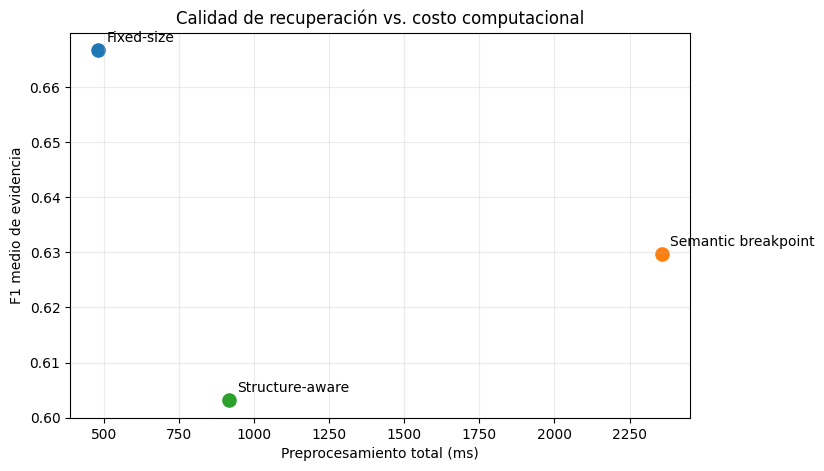

In [ ]:
# Relación entre F1 y tiempo total de preprocesamiento.
plt.figure(figsize=(8, 5))

for _, row in results.iterrows():
    plt.scatter(row["total_ms"], row["f1"], s=90)
    plt.annotate(
        row["chunker"],
        (row["total_ms"], row["f1"]),
        xytext=(6, 6),
        textcoords="offset points",
    )

plt.xlabel("Preprocesamiento total (ms)")
plt.ylabel("F1 medio de evidencia")
plt.title("Calidad de recuperación vs. costo computacional")
plt.grid(alpha=0.25)
plt.show()

## **Interpretación general**

Con este ejercicio buscamos mostrar que escoger una estrategia de chunking no es solamente una decisión basada en “cuál obtuvo el F1 más alto”. Nosotros la estamos viendo como una decisión de ingeniería en la que también importa cuánto trabajo adicional requiere cada método.

**Fixed-size** nos da una opción simple y barata. **Semantic breakpoint** incorpora información semántica antes de decidir los cortes. Con **Structure-aware** quisimos probar un punto intermedio: aprovechar información que ya existe en el documento, como los párrafos, sin hacer un análisis semántico adicional para cada separación.

La idea no es asumir desde el inicio que Structure-aware va a ser mejor. Lo que queremos comprobar es si respetar la estructura del documento puede dar una segmentación útil con un costo menor que una estrategia semántica.

Por eso nuestra comparación gira alrededor de tres elementos:

**calidad de recuperación + estructura del documento + costo computacional.**


## **Referencia principal**

[1] R. Qu, R. Tu y F. Bao, **“Is Semantic Chunking Worth the Computational Cost?”**, *Findings of the Association for Computational Linguistics: NAACL 2025*, pp. 2155–2177, 2025.  
DOI: `10.18653/v1/2025.findings-naacl.114`

---

## **Preguntas**

**1. ¿Qué es un chunk en un sistema RAG?**  
Es una parte más pequeña de un documento que usamos como unidad para buscar y recuperar información.

**2. ¿Qué hicimos en Fixed-size chunking?**  
Agrupar una cantidad fija de oraciones sin analizar primero su significado.

**3. ¿Cómo decide Semantic breakpoint dónde cortar?**  
Comparando los embeddings de oraciones consecutivas y usamos los cambios semánticos más fuertes como puntos de corte.

**4. ¿Por qué Semantic breakpoint puede costar más?**  
Porque antes de construir los chunks necesitamos calcular embeddings de las oraciones para decidir las separaciones.

**5. ¿Qué quisimos aprovechar con Structure-aware?**  
La estructura que ya existe en el documento, principalmente los límites entre párrafos.

**6. ¿Para qué utilizamos la similitud coseno?**  
Se usa para comparar la pregunta con los chunks y ordenar los fragmentos según qué tan relacionados están.

**7. ¿Qué nos dice Precision?**  
Nos dice qué parte de lo que recuperamos realmente correspondía a la evidencia esperada.

**8. ¿Qué nos dice Recall?**  
Nos muestra qué parte de toda la evidencia correcta logramos encontrar.

**9. ¿Por qué miramos F1?**  
Porque nos permite combinar Precision y Recall y tener una medida más equilibrada.

**10. ¿Qué ventaja buscamos comprobar con Structure-aware frente a Semantic breakpoint?**  
Ver si aprovechar la estructura natural del documento, como párrafos o secciones, puede mantener una buena calidad de recuperación sin necesitar el costo adicional de calcular embeddings para decidir los cortes.